In [14]:
from concurrent.futures import ProcessPoolExecutor
from tqdm import tqdm
import json
from pathlib import Path
import sys
import warnings

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np

sys.path.insert(0, str(Path("..").resolve()))

from _simulation_workers import (
    generate_scenario1,
    generate_scenario2,
    generate_scenario3,
    init_globals,
    r_stability_worker,
    sweep_worker,
)

from geomexp.visualization import ClusterVisualizer, PlotStyle

warnings.filterwarnings("ignore")

_viridis = mpl.colormaps["viridis"]
_viridis_colors = [mpl.colors.to_hex(_viridis(i / 4)) for i in range(5)]

style = PlotStyle(figsize=(3, 4), use_latex=True, fontsize=16, color_palette=_viridis_colors)
viz = ClusterVisualizer(style)

PLOT_DIR = Path("../plots/simulation")
PLOT_DIR.mkdir(parents=True, exist_ok=True)

RESULTS_DIR = Path("../results/simulation")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

N_MC = 50
N_RESTARTS = 10
K = 3
MAX_WORKERS = 8

init_globals(K, N_RESTARTS)

In [15]:
def run_sweep_study(generate_fn, param_name, param_values, n_mc=N_MC, base_seed=0):
    """Run a full MC study sweeping one DGP parameter."""
    all_args = []
    for val in param_values:
        kwargs = {param_name: val}
        for mc in range(n_mc):
            all_args.append((base_seed + mc, generate_fn, kwargs, val))

    with ProcessPoolExecutor(
        max_workers=MAX_WORKERS,
        initializer=init_globals,
        initargs=(K, N_RESTARTS),
    ) as pool:
        raw_results = list(pool.map(sweep_worker, all_args))

    grouped = {}
    for val, res in raw_results:
        grouped.setdefault(val, []).append(res)

    summary = {}
    for val in param_values:
        reps = grouped[val]
        s = {}
        for method in ["kmeans", "gec"]:
            metrics = {}
            for key in ["ari", "vi", "miscl", "runtime"]:
                vals_list = [r[method][key] for r in reps]
                metrics[key] = {"mean": float(np.mean(vals_list)),
                                "std": float(np.std(vals_list))}
            s[method] = metrics
        s["selected_r"] = {
            "mean": float(np.mean([r["selected_r"] for r in reps])),
            "std": float(np.std([r["selected_r"] for r in reps])),
        }
        summary[val] = s

    return summary, grouped


def print_sweep_summary(name, param_label, summary):
    print(f"\n{'='*70}")
    print(f"  {name} -- sweep over {param_label}")
    print(f"{'='*70}")
    for val in sorted(summary.keys()):
        s = summary[val]
        sel_r = s["selected_r"]
        print(f"\n  {param_label} = {val}")
        print(f"  Selected r: {sel_r['mean']:.3f} ({sel_r['std']:.3f})")
        print(f"  {'Metric':<15} {'k-means':>20} {'GEC':>20}")
        print(f"  {'-'*55}")
        for key, label in [("ari", "ARI"), ("vi", "VI"),
                           ("miscl", "Miscl. error"), ("runtime", "Runtime (s)")]:
            km = s["kmeans"][key]
            gc = s["gec"][key]
            print(f"  {label:<15} {km['mean']:>8.3f} ({km['std']:.3f})"
                  f" {gc['mean']:>8.3f} ({gc['std']:.3f})")

In [16]:
def plot_ari_sweep(summary, param_label, filename):
    """Plot ARI vs swept parameter for k-means and GEC."""
    vals = sorted(summary.keys())
    km_mean = [summary[v]["kmeans"]["ari"]["mean"] for v in vals]
    km_std = [summary[v]["kmeans"]["ari"]["std"] for v in vals]
    gec_mean = [summary[v]["gec"]["ari"]["mean"] for v in vals]
    gec_std = [summary[v]["gec"]["ari"]["std"] for v in vals]

    fig, ax = plt.subplots(figsize=style.figsize)
    ax.errorbar(vals, km_mean, yerr=km_std, label="k-means", marker="o",
                markersize=3, linewidth=1, capsize=2, color=style.color_palette[0])
    ax.errorbar(vals, gec_mean, yerr=gec_std, label="GEC", marker="s",
                markersize=3, linewidth=1, capsize=2, color=style.color_palette[1])
    ax.set_xlabel(param_label)
    ax.set_ylabel(r"ARI")
    ax.legend(frameon=True, edgecolor="black", fancybox=False)
    ax.grid(True, alpha=style.grid_alpha, linewidth=style.grid_linewidth)
    fig.tight_layout()
    fig.savefig(PLOT_DIR / filename, bbox_inches="tight")
    plt.show()
    return fig

In [17]:
def fmt(mean, std, bold=False):
    s = f"{mean:.3f} ({std:.3f})"
    return rf"\textbf{{{s}}}" if bold else s


METRIC_LABELS = [
    ("ari", "ARI", True),
    ("vi", "VI", False),
    ("miscl", "Miscl.\\ error", False),
    ("runtime", "Runtime (s)", False),
]


def _bold_flags(key, km_mean, gc_mean, higher_better):
    if key == "runtime":
        return False, False
    if higher_better:
        return km_mean > gc_mean, gc_mean > km_mean
    return km_mean < gc_mean, gc_mean < km_mean


def latex_combined_table(scenario_studies):
    """Generate one LaTeX table combining all scenarios.

    Parameters
    ----------
    scenario_studies : list of (scenario_name, param_latex, summary) tuples.
        Each summary is {param_value: {method: {metric: {mean, std}}, ...}}.
    """
    caption = (
        r"Simulation results across three DGPs. Entries are means (std) over "
        f"{N_MC} Monte Carlo replications. "
        r"Best values per metric are in \textbf{bold}."
    )
    lines = [
        r"\begin{table}[ht]",
        r"\centering",
        r"\small",
        rf"\caption{{{caption}}}",
        r"\label{tab:simulation}",
        r"\begin{tabular}{ll l rr}",
        r"\toprule",
        r"Scenario & Setting & Metric & k-means & GEC \\",
        r"\midrule",
    ]
    for sc_idx, (sc_name, param_latex, summary) in enumerate(scenario_studies):
        vals = sorted(summary.keys())
        for vi, val in enumerate(vals):
            s = summary[val]
            for j, (key, label, higher_better) in enumerate(METRIC_LABELS):
                km, gc = s["kmeans"][key], s["gec"][key]
                km_b, gc_b = _bold_flags(
                    key, km["mean"], gc["mean"], higher_better,
                )
                sc_col = sc_name if vi == 0 and j == 0 else ""
                setting = f"${param_latex}={val}$" if j == 0 else ""
                lines.append(
                    f"  {sc_col} & {setting} & {label} & "
                    f"{fmt(km['mean'], km['std'], km_b)} & "
                    f"{fmt(gc['mean'], gc['std'], gc_b)} \\\\"
                )
            if vi < len(vals) - 1:
                lines.append(r"  \addlinespace")
        if sc_idx < len(scenario_studies) - 1:
            lines.append(r"\midrule")
    lines += [r"\bottomrule", r"\end{tabular}", r"\end{table}"]
    print("\n".join(lines))

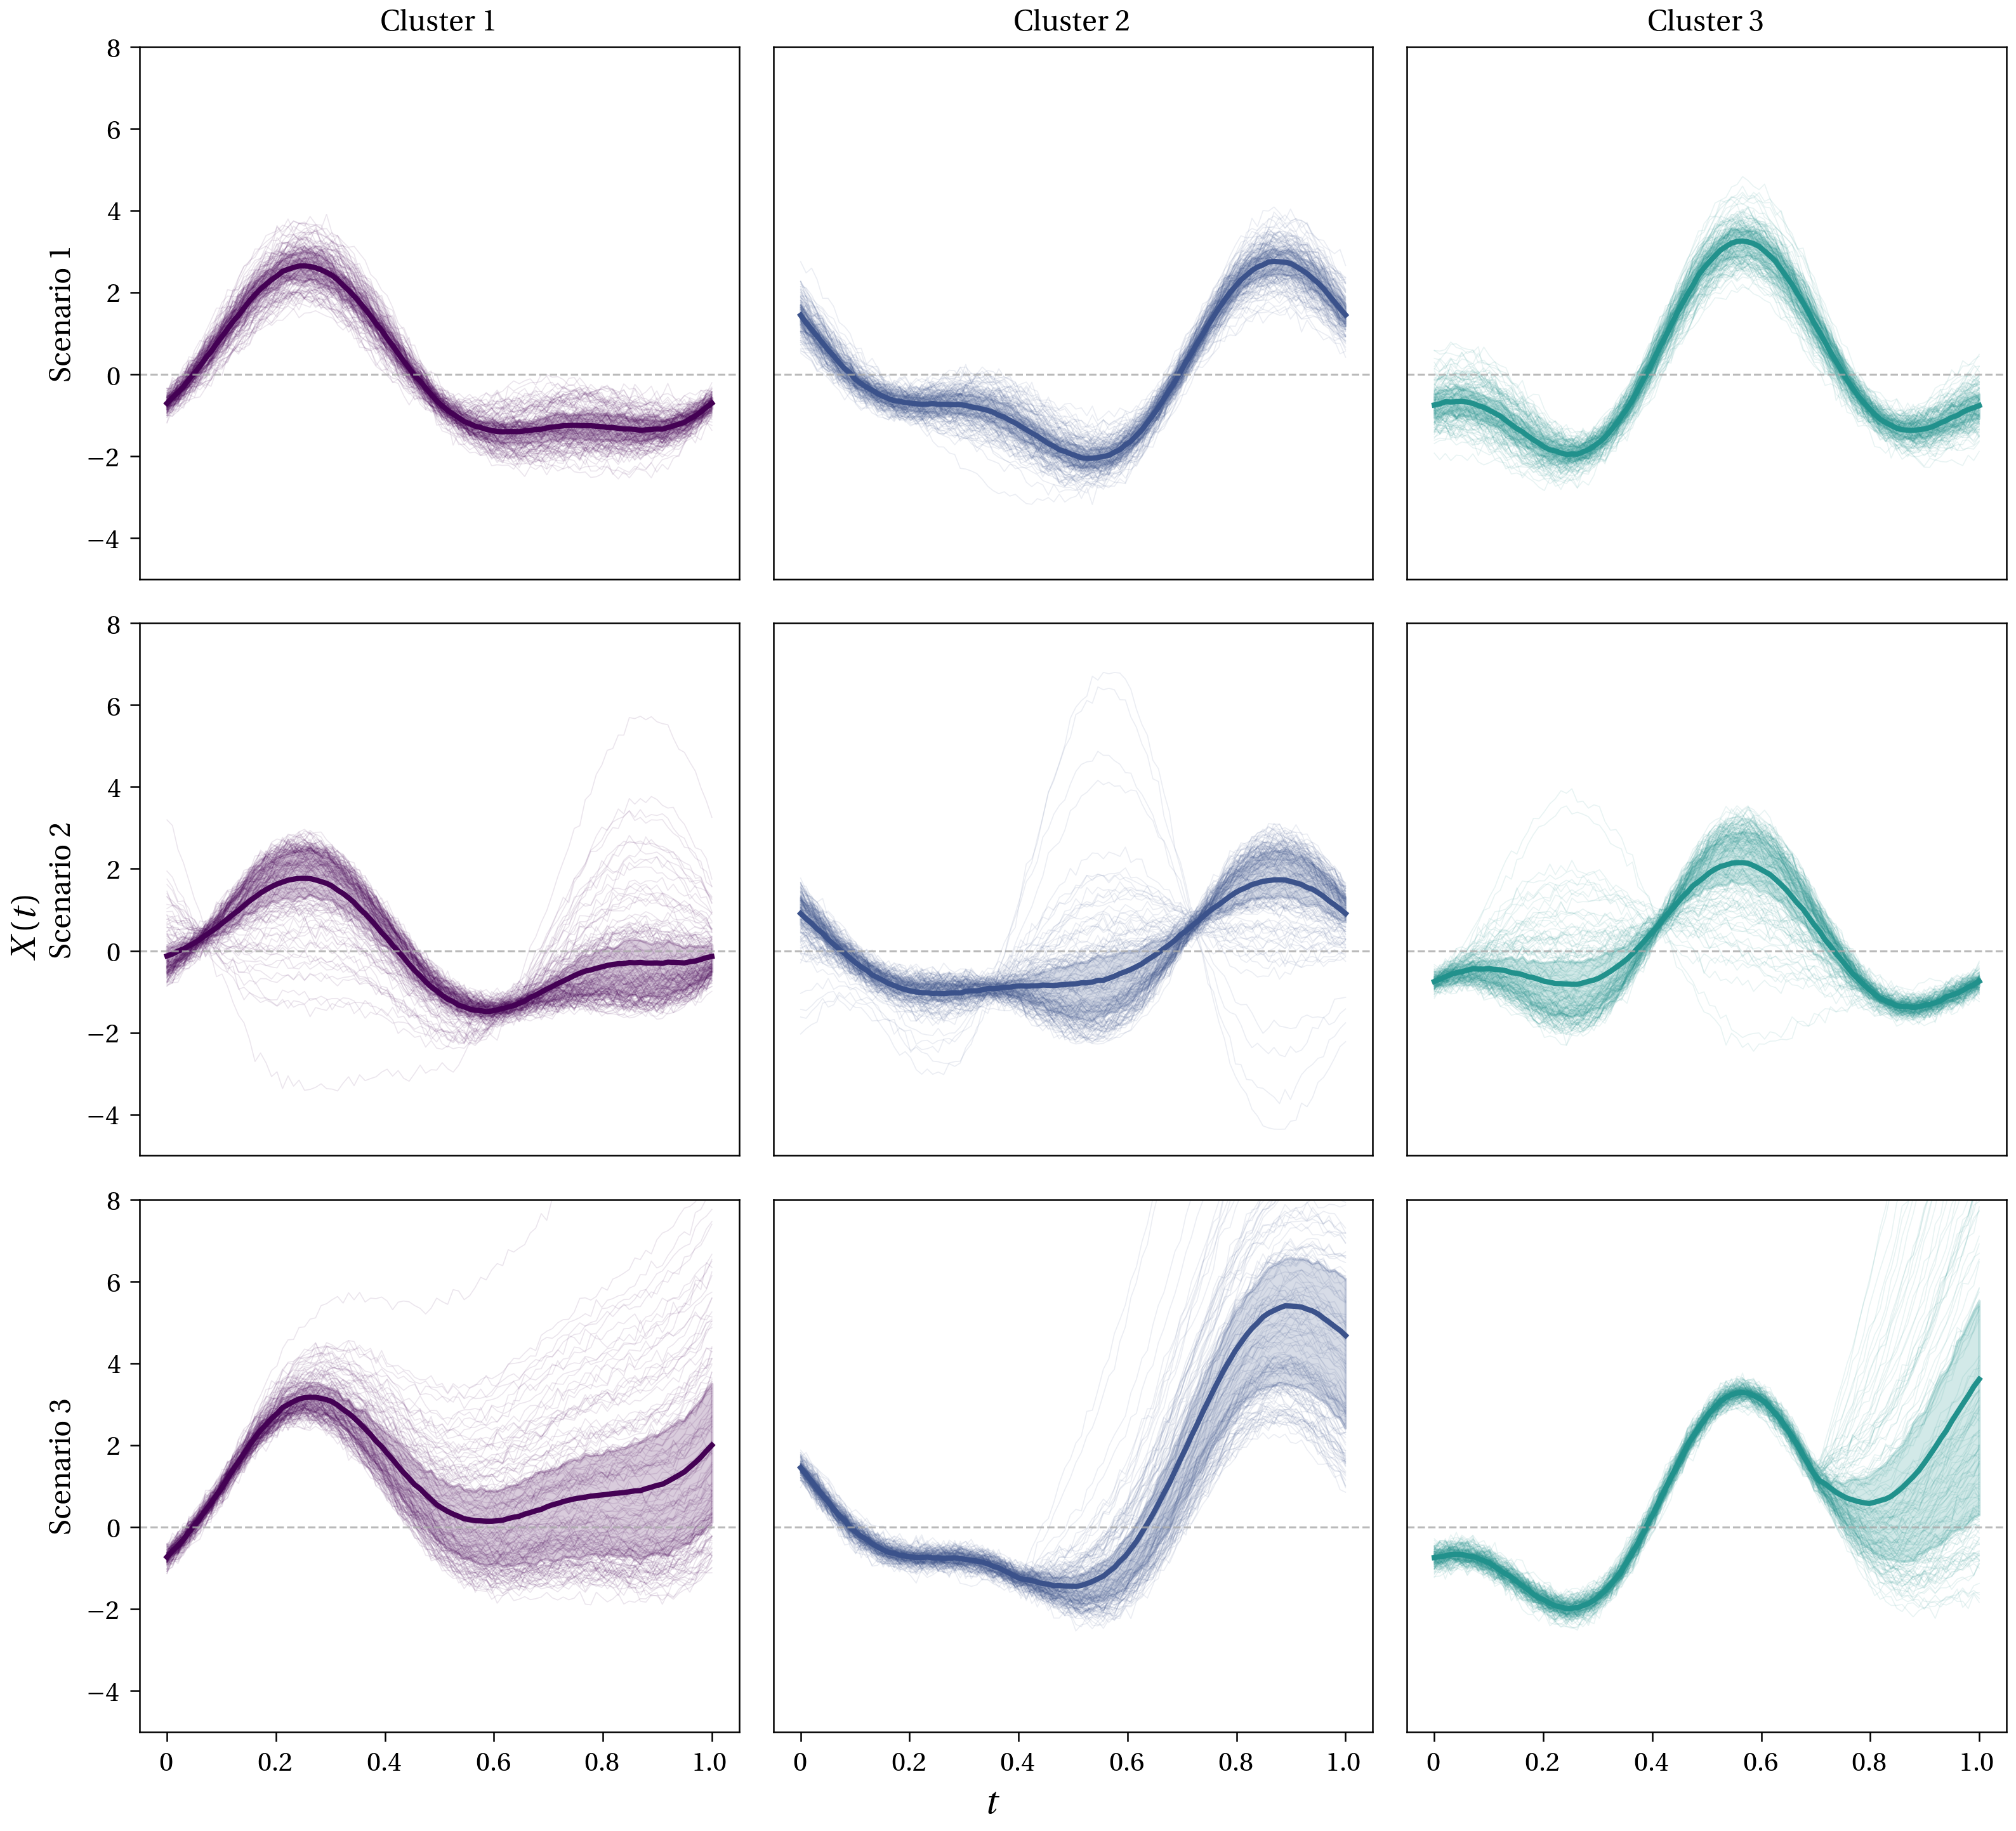

In [32]:
rng_plot = np.random.default_rng(0)
t_plot = np.linspace(0, 1, 100)

scenarios = [
    ("Scenario 1", generate_scenario1, {}),
    ("Scenario 2", generate_scenario2, {}),
    ("Scenario 3", generate_scenario3, {}),
]

from matplotlib.ticker import FuncFormatter

style.fontsize = 12
viz._setup_matplotlib()
fig, axes = plt.subplots(len(scenarios), K, figsize=(11, 10), sharey=True, sharex=True)
x_tick_formatter = FuncFormatter(lambda x, pos: '0' if np.isclose(x, 0.0) else f'{x:.1f}')

for row, (title, gen_fn, kwargs) in enumerate(scenarios):
    X_ex, y_ex = gen_fn(seed=69, **kwargs)
    for k in range(K):
        ax = axes[row, k]
        mask = y_ex == k
        color = style.color_palette[k % len(style.color_palette)]

        cluster_curves = X_ex[mask]
        mean_curve = cluster_curves.mean(axis=0)
        q1 = np.percentile(cluster_curves, 25, axis=0)
        q3 = np.percentile(cluster_curves, 75, axis=0)

        # Individual curves with low opacity
        for curve in cluster_curves:
            ax.plot(t_plot, curve, color=color, alpha=0.1, linewidth=0.4)

        # IQR shaded band
        ax.fill_between(t_plot, q1, q3, color=color, alpha=0.2)

        # Mean curve
        ax.plot(t_plot, mean_curve, color=color, linewidth=2)

        # Dashed reference line at zero
        ax.axhline(0, color="darkgrey", linewidth=0.75, linestyle="--", alpha=0.8)

        if row == 0:
            ax.set_title(f"Cluster {k + 1}")
        if k == 0:
            ax.set_ylabel(title)
        else:
            ax.tick_params(axis="y", which="both", left=False, labelleft=False)

        ax.set_ylim(-5, 8)
        ax.set_yticks([-4, -2, 0, 2, 4, 6, 8])
        ax.xaxis.set_major_formatter(x_tick_formatter)

        # Clean: no gridlines, minimal spines
        ax.grid(False)

        if row < len(scenarios) - 1:
            ax.tick_params(axis="x", labelbottom=False, length=0)


fig.subplots_adjust(left=0.1, wspace=0.0, hspace=0.0)
fig.supxlabel("$t$", y=0.03)
fig.supylabel("$X(t)$", x=0.03)
plt.tight_layout()
fig.savefig(PLOT_DIR / "dgp_overview.pdf", bbox_inches="tight")
plt.show()

In [19]:
sigma_eps_values = np.round(np.arange(0.1, 1.4, 0.3), decimals=1)
summary1, grouped1 = run_sweep_study(
    generate_scenario1, "sigma_eps", sigma_eps_values, base_seed=1000
)
print_sweep_summary("Scenario 1", r"$\sigma_\varepsilon$", summary1)

KeyboardInterrupt: 

In [ ]:
# Sweep tau (tail strength) with R=2.0, sigma_c=0.1
tau_values_s2 = np.arange(0.2, 1.5, 0.3)
summary2_tau, grouped2_tau = run_sweep_study(
    generate_scenario2, "tau", tau_values_s2, base_seed=2000
)
print_sweep_summary("Scenario 2 (tau sweep)", r"$\tau$", summary2_tau)

In [ ]:
tau_values_s3 = np.arange(0.2, 1.5, 0.3)
summary3, grouped3 = run_sweep_study(
    generate_scenario3, "tau", tau_values_s3, base_seed=3000
)
print_sweep_summary("Scenario 3", r"$\tau$", summary3)

In [ ]:
def _convert_keys(summary):
    """Convert numeric keys to strings for JSON serialization."""
    return {str(k): v for k, v in summary.items()}

def _restore_keys(summary):
    """Restore string keys back to floats."""
    return {float(k): v for k, v in summary.items()}

with open(RESULTS_DIR / "scenario1_sweep.json", "w") as f:
    json.dump(_convert_keys(summary1), f, indent=2)
with open(RESULTS_DIR / "scenario2_tau_sweep.json", "w") as f:
    json.dump(_convert_keys(summary2_tau), f, indent=2)
with open(RESULTS_DIR / "scenario3_sweep.json", "w") as f:
    json.dump(_convert_keys(summary3), f, indent=2)

In [ ]:
with open(RESULTS_DIR / "scenario1_sweep.json") as f:
    summary1 = _restore_keys(json.load(f))
with open(RESULTS_DIR / "scenario2_tau_sweep.json") as f:
    summary2_tau = _restore_keys(json.load(f))
with open(RESULTS_DIR / "scenario3_sweep.json") as f:
    summary3 = _restore_keys(json.load(f))

In [ ]:
latex_combined_table([
    ("Scenario 1", r"\sigma_\varepsilon", summary1),
    ("Scenario 2", r"\tau", summary2_tau),
    ("Scenario 3", r"\tau", summary3),
])

In [20]:
STABILITY_N_GRID = 100
STABILITY_TAU_VALUES = np.linspace(0, 1.4, STABILITY_N_GRID)
STABILITY_R_GRID = np.linspace(0, 0.99, STABILITY_N_GRID)
STABILITY_N_MC = 25 #N_MC
STABILITY_SEED_S2 = 5000
STABILITY_SEED_S3 = 6000
STABILITY_SHOW_OVERLAY = True
STABILITY_OVERLAY_LAMBDAS = [2.0, 1.5]
STABILITY_OVERLAY_N_MC = 25

In [21]:
def _save_stability_results(results, filename):
    data = {
        'heatmap': results['heatmap'].tolist(),
        'selected_r_mean': results['selected_r_mean'].tolist(),
        'selected_r_std': results['selected_r_std'].tolist(),
        'tau_values': results['tau_values'].tolist(),
        'r_grid': results['r_grid'].tolist(),
    }
    with open(RESULTS_DIR / filename, 'w') as f:
        json.dump(data, f, indent=2)


def _load_stability_results(filename):
    with open(RESULTS_DIR / filename) as f:
        data = json.load(f)
    return {
        'heatmap': np.array(data['heatmap']),
        'selected_r_mean': np.array(data['selected_r_mean']),
        'selected_r_std': np.array(data['selected_r_std']),
        'tau_values': np.array(data['tau_values']),
        'r_grid': np.array(data['r_grid']),
    }


def _save_lambda_overlay_results(results, filename):
    payload = {
        'tau_values': results['tau_values'].tolist(),
        'lambdas': [float(x) for x in results['lambdas']],
        'overlays': {
            f'{lam:.4f}': {
                'selected_r_mean': vals['selected_r_mean'].tolist(),
                'selected_r_std': vals['selected_r_std'].tolist(),
            }
            for lam, vals in results['overlays'].items()
        },
    }
    with open(RESULTS_DIR / filename, 'w') as f:
        json.dump(payload, f, indent=2)


def _load_lambda_overlay_results(filename):
    with open(RESULTS_DIR / filename) as f:
        data = json.load(f)

    overlays = {}
    for lam_key, vals in data['overlays'].items():
        overlays[float(lam_key)] = {
            'selected_r_mean': np.array(vals['selected_r_mean']),
            'selected_r_std': np.array(vals['selected_r_std']),
        }

    return {
        'tau_values': np.array(data['tau_values']),
        'lambdas': np.array(data['lambdas'], dtype=float),
        'overlays': overlays,
    }


def run_r_stability_study(generate_fn, tau_values, r_grid, n_mc, base_seed):
    all_args = []
    for tau in tau_values:
        for mc in range(n_mc):
            all_args.append((base_seed + mc, generate_fn, {}, tau, r_grid))

    print(f"Running {len(all_args)} tasks...")
    with ProcessPoolExecutor(
        max_workers=MAX_WORKERS,
        initializer=init_globals,
        initargs=(K, N_RESTARTS),
    ) as pool:
        from concurrent.futures import as_completed
        futures = [pool.submit(r_stability_worker, args) for args in all_args]
        raw_results = []
        for future in tqdm(as_completed(futures), total=len(futures), desc='R-stability'):
            raw_results.append(future.result())

    n_tau = len(tau_values)
    n_r = len(r_grid)
    miscl_by_tau = {round(tau, 4): [] for tau in tau_values}
    selected_r_by_tau = {round(tau, 4): [] for tau in tau_values}

    for seed, tau, sel_r, miscl_errors in raw_results:
        tau_key = round(tau, 4)
        miscl_by_tau[tau_key].append(miscl_errors)
        selected_r_by_tau[tau_key].append(sel_r)

    heatmap = np.zeros((n_tau, n_r))
    for i, tau in enumerate(tau_values):
        tau_key = round(tau, 4)
        heatmap[i, :] = np.mean(miscl_by_tau[tau_key], axis=0)

    selected_r_mean = np.array([np.mean(selected_r_by_tau[round(tau, 4)]) for tau in tau_values])
    selected_r_std = np.array([np.std(selected_r_by_tau[round(tau, 4)]) for tau in tau_values])

    return {
        'heatmap': heatmap,
        'selected_r_mean': selected_r_mean,
        'selected_r_std': selected_r_std,
        'tau_values': np.array(tau_values),
        'r_grid': np.array(r_grid),
    }


def run_selected_r_lambda_overlays(generate_fn, tau_values, lambdas, n_mc, base_seed):
    all_args = []
    for tau in tau_values:
        for lam in lambdas:
            for mc in range(n_mc):
                all_args.append((base_seed + mc, generate_fn, {}, tau, float(lam)))

    print(f"Running {len(all_args)} lambda-overlay tasks...")
    with ProcessPoolExecutor(
        max_workers=MAX_WORKERS,
        initializer=init_globals,
        initargs=(K, N_RESTARTS),
    ) as pool:
        from concurrent.futures import as_completed
        import importlib
        import _simulation_workers as _sw

        _sw = importlib.reload(_sw)
        if not hasattr(_sw, 'selected_r_lambda_worker'):
            raise RuntimeError('selected_r_lambda_worker missing in _simulation_workers; restart kernel and re-run setup.')

        futures = [pool.submit(_sw.selected_r_lambda_worker, args) for args in all_args]
        raw_results = []
        for future in tqdm(as_completed(futures), total=len(futures), desc='Lambda overlay'):
            raw_results.append(future.result())

    per_lambda = {float(lam): {round(tau, 4): [] for tau in tau_values} for lam in lambdas}
    for seed, tau, lam, selected_r in raw_results:
        per_lambda[float(lam)][round(tau, 4)].append(float(selected_r))

    overlays = {}
    for lam in lambdas:
        lam = float(lam)
        mean_vals = np.array([np.mean(per_lambda[lam][round(tau, 4)]) for tau in tau_values])
        std_vals = np.array([np.std(per_lambda[lam][round(tau, 4)]) for tau in tau_values])
        overlays[lam] = {
            'selected_r_mean': mean_vals,
            'selected_r_std': std_vals,
        }

    return {
        'tau_values': np.array(tau_values),
        'lambdas': np.array(lambdas, dtype=float),
        'overlays': overlays,
    }


In [22]:
# stability_s2 = run_r_stability_study(
#     generate_scenario2, STABILITY_TAU_VALUES, STABILITY_R_GRID, STABILITY_N_MC, STABILITY_SEED_S2
# )

In [23]:
# _save_stability_results(stability_s2, 'stability_scenario2.json')

In [24]:
# stability_s3 = run_r_stability_study(
#     generate_scenario3, STABILITY_TAU_VALUES, STABILITY_R_GRID, STABILITY_N_MC, STABILITY_SEED_S3
# )

In [25]:
# _save_stability_results(stability_s3, 'stability_scenario3.json')

In [26]:
stability_s2 = _load_stability_results('stability_scenario2.json')
stability_s3 = _load_stability_results('stability_scenario3.json')

In [27]:
# Self-contained lambda-overlay computation (does NOT rerun heatmap/grid study)
import _simulation_workers as _sw

OVERLAY_LAMBDAS = [2.0, 1.5]
OVERLAY_N_MC = 25

overlay_tau_values = np.array(stability_s2['tau_values'])
if not np.allclose(overlay_tau_values, stability_s3['tau_values']):
    raise ValueError('stability_s2 and stability_s3 tau grids must match for lambda overlays.')

if not hasattr(_sw, 'selected_r_lambda_worker'):
    raise RuntimeError('selected_r_lambda_worker missing in _simulation_workers.py')

def _save_overlay_cache(payload, filename):
    with open(RESULTS_DIR / filename, 'w') as f:
        json.dump(payload, f, indent=2)


def _load_overlay_cache(filename):
    with open(RESULTS_DIR / filename) as f:
        data = json.load(f)
    overlays = {}
    for lam_key, vals in data['overlays'].items():
        overlays[float(lam_key)] = {
            'selected_r_mean': np.array(vals['selected_r_mean']),
            'selected_r_std': np.array(vals['selected_r_std']),
        }
    return {
        'tau_values': np.array(data['tau_values']),
        'lambdas': np.array(data['lambdas'], dtype=float),
        'overlays': overlays,
    }


def _run_overlay_for_scenario(generate_fn, base_seed, cache_file):
    cache_path = RESULTS_DIR / cache_file
    if cache_path.exists():
        return _load_overlay_cache(cache_file)

    all_args = []
    for tau in overlay_tau_values:
        for lam in OVERLAY_LAMBDAS:
            for mc in range(OVERLAY_N_MC):
                all_args.append((base_seed + mc, generate_fn, {}, float(tau), float(lam)))

    print(f'Running {len(all_args)} lambda-overlay tasks for {cache_file}...')
    with ProcessPoolExecutor(
        max_workers=MAX_WORKERS,
        initializer=_sw.init_globals,
        initargs=(K, N_RESTARTS),
    ) as pool:
        from concurrent.futures import as_completed
        futures = [pool.submit(_sw.selected_r_lambda_worker, args) for args in all_args]
        raw = [f.result() for f in tqdm(as_completed(futures), total=len(futures), desc='Lambda overlay')]

    per_lambda = {float(lam): {round(float(tau), 4): [] for tau in overlay_tau_values} for lam in OVERLAY_LAMBDAS}
    for seed, tau, lam, selected_r in raw:
        per_lambda[float(lam)][round(float(tau), 4)].append(float(selected_r))

    overlays = {}
    for lam in OVERLAY_LAMBDAS:
        lam = float(lam)
        means = np.array([np.mean(per_lambda[lam][round(float(tau), 4)]) for tau in overlay_tau_values])
        stds = np.array([np.std(per_lambda[lam][round(float(tau), 4)]) for tau in overlay_tau_values])
        overlays[lam] = {'selected_r_mean': means, 'selected_r_std': stds}

    payload = {
        'tau_values': overlay_tau_values.tolist(),
        'lambdas': [float(x) for x in OVERLAY_LAMBDAS],
        'overlays': {
            f'{lam:.4f}': {
                'selected_r_mean': vals['selected_r_mean'].tolist(),
                'selected_r_std': vals['selected_r_std'].tolist(),
            }
            for lam, vals in overlays.items()
        },
    }
    _save_overlay_cache(payload, cache_file)

    return {
        'tau_values': overlay_tau_values,
        'lambdas': np.array(OVERLAY_LAMBDAS, dtype=float),
        'overlays': overlays,
    }


stability_lambda_overlays_s2 = _run_overlay_for_scenario(
    _sw.generate_scenario2,
    STABILITY_SEED_S2 + 100_000,
    'stability_lambda_overlay_scenario2.json',
)
stability_lambda_overlays_s3 = _run_overlay_for_scenario(
    _sw.generate_scenario3,
    STABILITY_SEED_S3 + 100_000,
    'stability_lambda_overlay_scenario3.json',
)


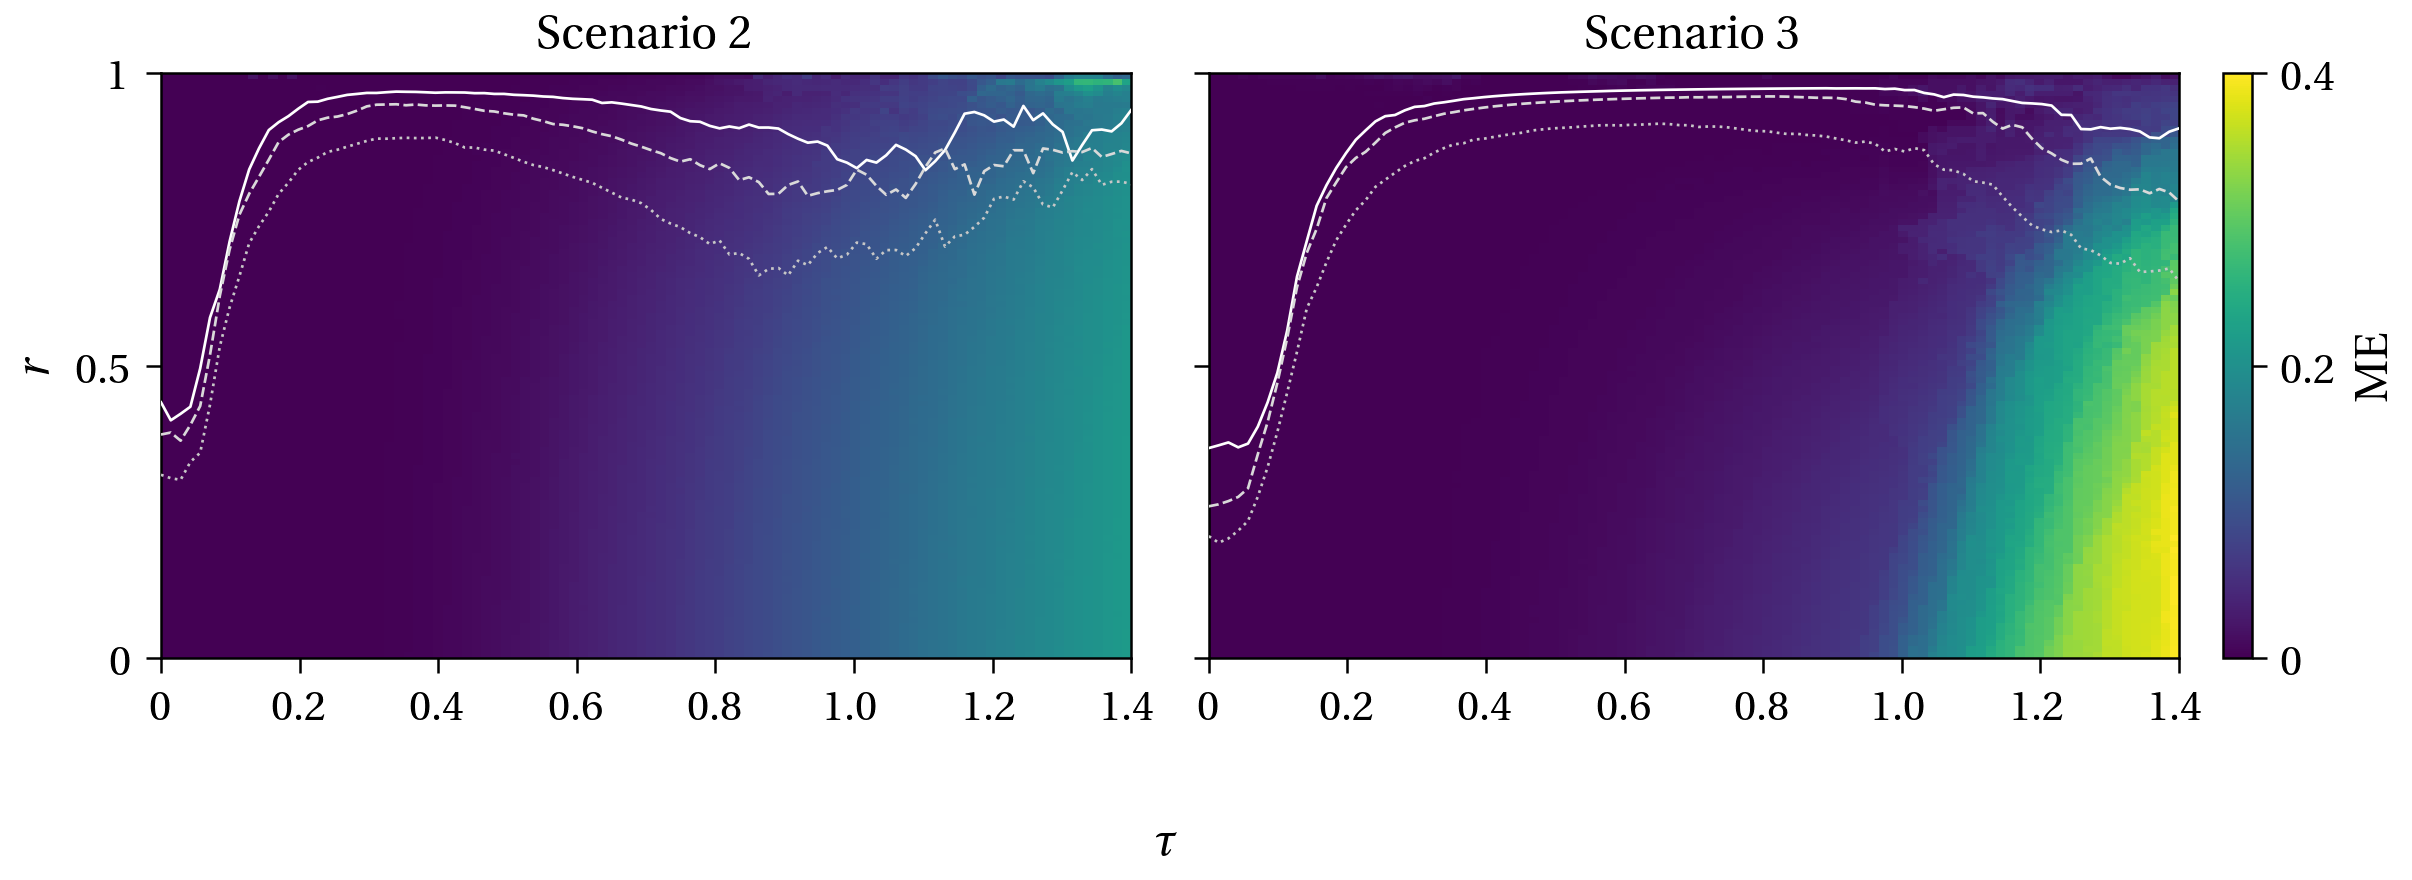

In [34]:
def plot_r_stability_heatmap(results_list, scenario_names, filename, show_overlay=True, lambda_overlays_list=None):
    n_scenarios = len(results_list)
    if lambda_overlays_list is None:
        lambda_overlays_list = [None] * n_scenarios

    all_heatmaps = np.concatenate([r['heatmap'].flatten() for r in results_list])
    vmin, vmax = all_heatmaps.min(), all_heatmaps.max()
    r_grid = results_list[0]['r_grid']
    tau_values = results_list[0]['tau_values']

    from matplotlib.ticker import FuncFormatter

    style.fontsize = 12
    viz._setup_matplotlib()
    plt.close('all')

    fig, axes = plt.subplots(1, n_scenarios, figsize=(11, 3), sharex=True, sharey=True)
    if n_scenarios == 1:
        axes = [axes]

    extra_styles = {
        2.0: {'color': '0.85', 'linestyle': '--'},
        1.5: {'color': '0.78', 'linestyle': ':'},
    }

    x_tick_formatter = FuncFormatter(lambda x, pos: '0' if np.isclose(x, 0.0) else f'{x:.1f}')

    for i, (ax, results, name, lambda_overlay_pack) in enumerate(zip(axes, results_list, scenario_names, lambda_overlays_list)):
        heatmap = results['heatmap']
        sel_r_mean = results['selected_r_mean']
        sel_r_std = results['selected_r_std']

        im = ax.imshow(
            heatmap.T,
            aspect='auto',
            origin='lower',
            extent=[tau_values[0], tau_values[-1], r_grid[0], 1.0],
            cmap='viridis',
            vmin=vmin,
            vmax=vmax,
        )

        if show_overlay:
            lower = np.clip(sel_r_mean - sel_r_std, r_grid[0], r_grid[-1])
            upper = np.clip(sel_r_mean + sel_r_std, r_grid[0], r_grid[-1])
            ax.fill_between(
                tau_values,
                lower,
                upper,
                color='white',
                alpha=0,
                linewidth=0,
                zorder=3,
            )
            ax.plot(tau_values, sel_r_mean, color='white', linewidth=0.65, zorder=4)

            if lambda_overlay_pack is not None:
                overlays = lambda_overlay_pack['overlays']
                for lam, style_info in extra_styles.items():
                    if lam not in overlays:
                        continue
                    lam_mean = overlays[lam]['selected_r_mean']
                    lam_std = overlays[lam]['selected_r_std']
                    lam_low = np.clip(lam_mean - lam_std, r_grid[0], r_grid[-1])
                    lam_up = np.clip(lam_mean + lam_std, r_grid[0], r_grid[-1])

                    ax.fill_between(
                        tau_values,
                        lam_low,
                        lam_up,
                        color=style_info['color'],
                        alpha=0,
                        linewidth=0,
                        zorder=3,
                    )
                    ax.plot(
                        tau_values,
                        lam_mean,
                        color=style_info['color'],
                        linestyle=style_info['linestyle'],
                        linewidth=0.65,
                        zorder=4,
                    )

        ax.set_title(name)
        ax.set_ylim(r_grid[0], 1.0)
        ax.xaxis.set_major_formatter(x_tick_formatter)
        ax.set_yticks([0.0, 0.5, 1.0])
        if i == 0:
            ax.set_ylabel(r'$r$')
            ax.set_yticklabels(['0', '0.5', '1'])

    fig.subplots_adjust(right=0.86, bottom=0.23, wspace=0.08)
    fig.text(0.43, 0.0, r'$\tau$', ha='center', va='bottom')

    cbar = fig.colorbar(im, ax=axes, shrink=1.0, pad=0.018)
    cbar.set_ticks([0.0, 0.2, 0.4])
    cbar.set_ticklabels(['0', '0.2', '0.4'])
    cbar.set_label('ME')

    fig.savefig(PLOT_DIR / filename, bbox_inches='tight')
    plt.show()


_lambda_overlays_to_plot = None
if 'stability_lambda_overlays_s2' in globals() and 'stability_lambda_overlays_s3' in globals():
    _lambda_overlays_to_plot = [stability_lambda_overlays_s2, stability_lambda_overlays_s3]

plot_r_stability_heatmap(
    [stability_s2, stability_s3],
    ['Scenario 2', 'Scenario 3'],
    'r_stability_heatmap.pdf',
    show_overlay=STABILITY_SHOW_OVERLAY,
    lambda_overlays_list=_lambda_overlays_to_plot,
)
